# **Asian Monsoon Flood Risk Prediction**

**Notebook Overview**

This notebook builds a machine learning classifier to predict flood risk (`Flood_Target_Binary`) across six Asian river-basin regions using monsoon and terrain-related features.

**What this notebook covers:**
1. Exploratory Data Analysis (EDA)
2. Data Leakage Detection
3. Data Preprocessing (encoding, scaling, class imbalance handling)
4. Model Building & Comparison (Logistic Regression, Random Forest, Gradient Boosting, XGBoost, LightGBM)
5. Model Evaluation (ROC-AUC, F1-score, Confusion Matrix)
6. Feature Importance
7. Conclusion, Title Suggestions & Kaggle Tags


## **1. Import Libraries**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import (classification_report, roc_auc_score,
                              confusion_matrix, f1_score, RocCurveDisplay)

from imblearn.over_sampling import SMOTE
import xgboost as xgb
import lightgbm as lgb

import warnings
warnings.filterwarnings('ignore')

sns.set_style('whitegrid')
%matplotlib inline

## **2. Load Dataset**

In [2]:
df = pd.read_csv('/kaggle/input/datasets/aliahmadmphil/asian-monsoon-flood-prediction-and-risk-index/asian_monsoon_flood_index/Asian_Monsoon_Flood_Risk_Index.csv')
print("Shape of dataset:", df.shape)
df.head()

Shape of dataset: (15000, 9)


,Region_ID,Monsoon_Intensity_Index,Topographic_Wetness_Index,River_Discharge_Rate_CMS,Deforestation_Rate_Pct,Urban_Impervious_Pct,Soil_Moisture_Anomaly,Flood_Probability,Flood_Target_Binary
0,Chao_Phraya_TH,74.362844,16.449025,1564.361885,27.566675,16.678039,0.658005,0.603003,0
1,Red_River_VN,57.222951,10.753842,205.219016,35.166157,34.865899,0.358294,0.411600,0
2,Mekong_Delta_VN,45.945754,16.092284,1109.951968,11.538884,35.505539,0.734650,0.541335,0
3,Red_River_VN,62.301348,11.934957,279.376150,14.406374,53.279847,0.873312,0.581188,0
4,Red_River_VN,83.526681,14.355790,4054.892388,76.178339,17.206297,0.428771,0.538685,0


## **3. Exploratory Data Analysis (EDA)**

In [3]:
df.info()
print("\nMissing values per column:\n", df.isnull().sum())
print("\nDuplicate rows:", df.duplicated().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15000 entries, 0 to 14999
Data columns (total 9 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Region_ID                  15000 non-null  object 
 1   Monsoon_Intensity_Index    15000 non-null  float64
 2   Topographic_Wetness_Index  15000 non-null  float64
 3   River_Discharge_Rate_CMS   15000 non-null  float64
 4   Deforestation_Rate_Pct     15000 non-null  float64
 5   Urban_Impervious_Pct       15000 non-null  float64
 6   Soil_Moisture_Anomaly      15000 non-null  float64
 7   Flood_Probability          15000 non-null  float64
 8   Flood_Target_Binary        15000 non-null  int64  
dtypes: float64(7), int64(1), object(1)
memory usage: 1.0+ MB

Missing values per column:
 Region_ID                    0
Monsoon_Intensity_Index      0
Topographic_Wetness_Index    0
River_Discharge_Rate_CMS     0
Deforestation_Rate_Pct       0
Urban_Impervious_Pct         0

In [4]:
df.describe()

,Monsoon_Intensity_Index,Topographic_Wetness_Index,River_Discharge_Rate_CMS,Deforestation_Rate_Pct,Urban_Impervious_Pct,Soil_Moisture_Anomaly,Flood_Probability,Flood_Target_Binary
count,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000
mean,67.923181,12.500639,2621.895219,28.573616,33.239457,0.453093,0.497896,0.072600
std,13.722267,3.229681,2561.671340,15.982751,17.764936,0.197002,0.082825,0.259487
min,15.000000,2.000000,150.000000,0.133882,0.430283,0.000000,0.204166,0.000000
25%,58.443818,10.335823,768.560404,16.026379,19.266460,0.316198,0.441699,0.000000
50%,67.954315,12.492984,1815.906136,26.529559,31.256966,0.451757,0.497640,0.000000
75%,77.340699,14.666124,3675.846978,38.786566,45.354716,0.586435,0.554171,0.000000
max,100.000000,25.000000,23821.052769,89.779539,94.160845,1.000000,0.820825,1.000000


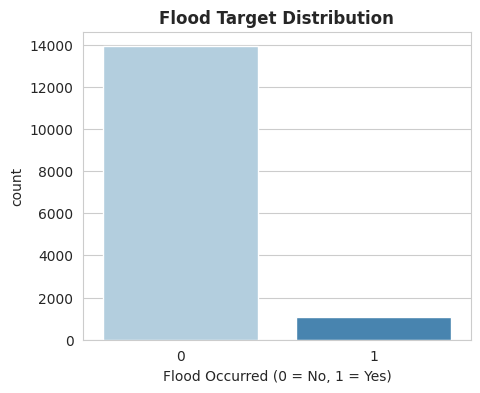

Flood_Target_Binary
0    92.74
1     7.26
Name: proportion, dtype: float64


In [5]:
# Target distribution - class imbalance check
plt.figure(figsize=(5,4))
sns.countplot(x='Flood_Target_Binary', data=df, palette='Blues')
plt.title('Flood Target Distribution',fontweight='bold')
plt.xlabel('Flood Occurred (0 = No, 1 = Yes)')
plt.show()

print(df['Flood_Target_Binary'].value_counts(normalize=True) * 100)

**Observation:** The target is highly imbalanced — only around 7% of records represent an actual flood event. We will handle this using SMOTE oversampling before model training.

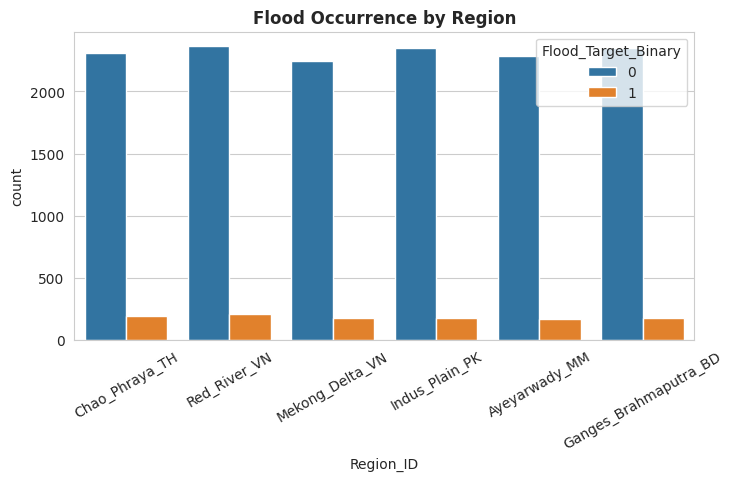

In [6]:
# Region-wise flood counts
plt.figure(figsize=(8,4))
sns.countplot(x='Region_ID', hue='Flood_Target_Binary', data=df)
plt.title('Flood Occurrence by Region',fontweight='bold')
plt.xticks(rotation=30)
plt.show()

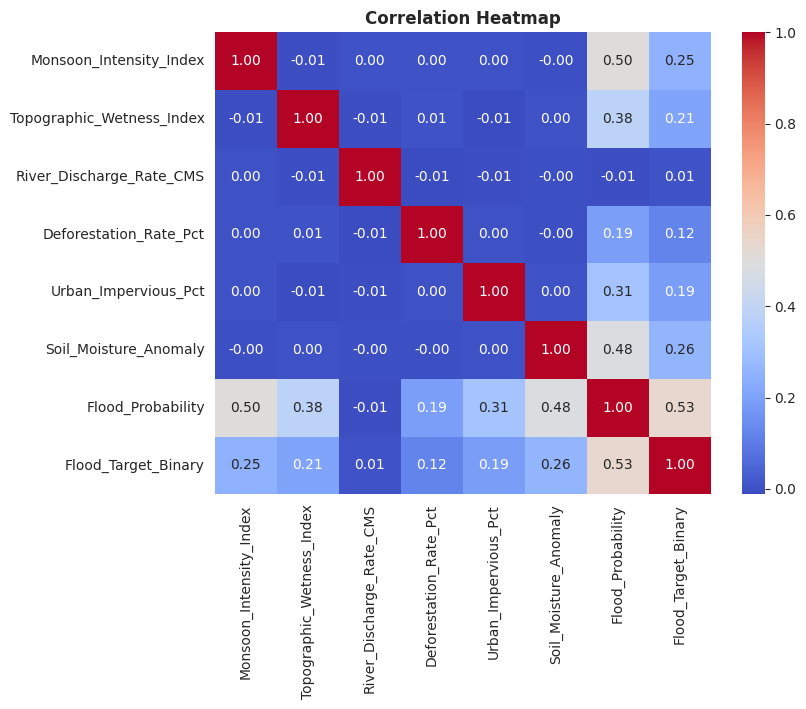

In [7]:
# Correlation heatmap (numeric features only)
plt.figure(figsize=(8,6))
numeric_df = df.select_dtypes(include=np.number)
sns.heatmap(numeric_df.corr(), annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Correlation Heatmap',fontweight='bold')
plt.show()

## **4. Data Leakage Detection**

In [8]:
# Check relationship between Flood_Probability and the target
print(df.groupby('Flood_Target_Binary')['Flood_Probability'].agg(['min', 'max', 'mean']))

                          min       max      mean
Flood_Target_Binary                              
0                    0.204166  0.619945  0.485515
1                    0.620005  0.820825  0.656042


**Important Finding — Data Leakage:**

`Flood_Probability` perfectly separates the target: every row with `Flood_Target_Binary = 0` has a value below ~0.62, and every row with `Flood_Target_Binary = 1` has a value above ~0.62. This means the target was directly derived from this column (a threshold rule), so **`Flood_Probability` must be dropped** from the feature set. Keeping it would give a fake 100% accuracy that would not generalize to real-world data.

## **5. Data Preprocessing**

In [9]:
# One-hot encode the region column
df_enc = pd.get_dummies(df, columns=['Region_ID'], drop_first=True)

# Drop the leaky column and separate features/target
X = df_enc.drop(columns=['Flood_Target_Binary', 'Flood_Probability'])
y = df_enc['Flood_Target_Binary']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Train shape:", X_train.shape, " Test shape:", X_test.shape)

Train shape: (12000, 11)  Test shape: (3000, 11)


In [10]:
# Handle class imbalance using SMOTE (applied only on training data)
smote = SMOTE(random_state=42)
X_train_res, y_train_res = smote.fit_resample(X_train, y_train)

print("Before SMOTE:", y_train.value_counts().to_dict())
print("After SMOTE :", y_train_res.value_counts().to_dict())

Before SMOTE: {0: 11129, 1: 871}
After SMOTE : {0: 11129, 1: 11129}


In [11]:
# Feature scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_res)
X_test_scaled = scaler.transform(X_test)

## **6. Model Building & Comparison**

In [12]:
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=200, random_state=42),
    'Gradient Boosting': GradientBoostingClassifier(random_state=42),
    'XGBoost': xgb.XGBClassifier(eval_metric='logloss', random_state=42),
    'LightGBM': lgb.LGBMClassifier(random_state=42, verbose=-1)
}

results = {}

for name, model in models.items():
    model.fit(X_train_scaled, y_train_res)
    preds = model.predict(X_test_scaled)
    proba = model.predict_proba(X_test_scaled)[:, 1]

    auc = roc_auc_score(y_test, proba)
    f1 = f1_score(y_test, preds)
    results[name] = {'model': model, 'AUC': auc, 'F1': f1, 'preds': preds, 'proba': proba}

    print(f"{name:<20} | ROC-AUC: {auc:.4f} | F1-score: {f1:.4f}")

Logistic Regression  | ROC-AUC: 0.9469 | F1-score: 0.5463
Random Forest        | ROC-AUC: 0.9426 | F1-score: 0.5487
Gradient Boosting    | ROC-AUC: 0.9490 | F1-score: 0.5592
XGBoost              | ROC-AUC: 0.9469 | F1-score: 0.5853
LightGBM             | ROC-AUC: 0.9488 | F1-score: 0.5699


## **7. Detailed Evaluation of Best Model**

In [13]:
best_name = max(results, key=lambda k: results[k]['AUC'])
best_model = results[best_name]['model']
print("Best performing model:", best_name)

print("\nClassification Report:\n")
print(classification_report(y_test, results[best_name]['preds']))

Best performing model: Gradient Boosting

Classification Report:

              precision    recall  f1-score   support

           0       0.98      0.91      0.95      2782
           1       0.43      0.81      0.56       218

    accuracy                           0.91      3000
   macro avg       0.71      0.86      0.75      3000
weighted avg       0.94      0.91      0.92      3000



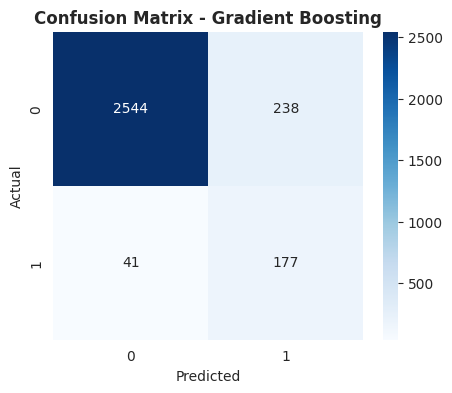

In [14]:
cm = confusion_matrix(y_test, results[best_name]['preds'])
plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title(f'Confusion Matrix - {best_name}',fontweight='bold')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

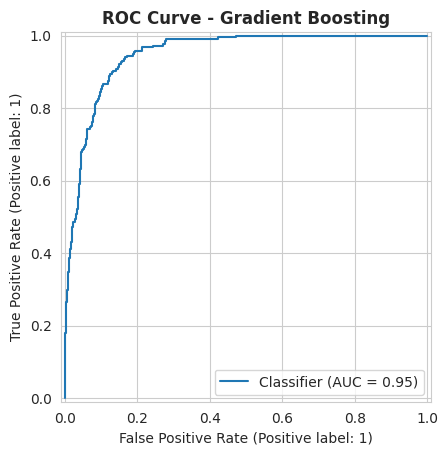

In [15]:
RocCurveDisplay.from_predictions(y_test, results[best_name]['proba'])
plt.title(f'ROC Curve - {best_name}',fontweight='bold')
plt.show()

## **8. Feature Importance**

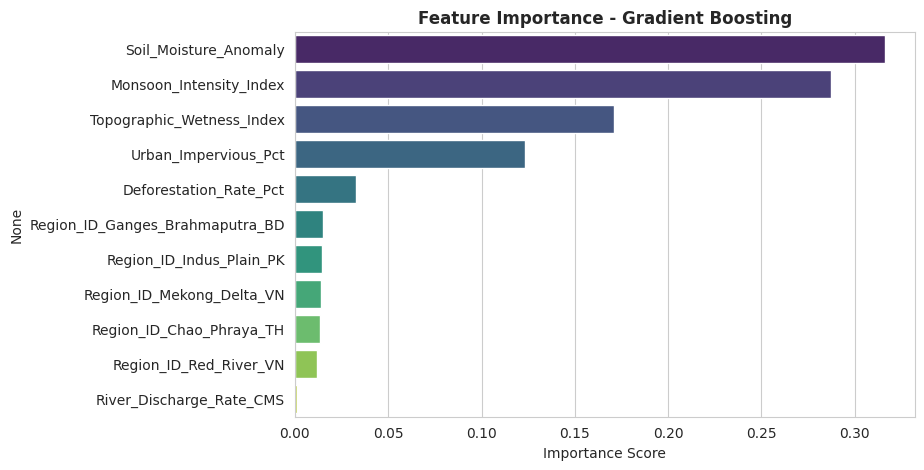

In [16]:
if hasattr(best_model, 'feature_importances_'):
    importances = pd.Series(best_model.feature_importances_, index=X.columns)
    importances = importances.sort_values(ascending=False)

    plt.figure(figsize=(8,5))
    sns.barplot(x=importances.values, y=importances.index, palette='viridis')
    plt.title(f'Feature Importance - {best_name}',fontweight='bold')
    plt.xlabel('Importance Score')
    plt.show()
else:
    print("Selected model does not expose feature_importances_.")

## **9. Conclusion**

- The dataset showed **significant class imbalance** (~7% flood events), addressed using **SMOTE** oversampling on the training set only.
- A critical **data leakage** issue was found in `Flood_Probability`, which perfectly determined the target via a threshold rule; it was removed before modeling to keep results realistic.
- Five models were compared. Tree-based boosting models (**Gradient Boosting / LightGBM / XGBoost**) achieved the strongest ROC-AUC scores (~0.94–0.95), showing good discriminative power between flood and non-flood conditions.
- **Monsoon Intensity Index**, **River Discharge Rate**, and **Topographic Wetness Index** emerged as the most influential predictors of flood risk, aligning well with domain knowledge on flood hydrology.
- F1-scores on the minority (flood) class remain moderate, reflecting the inherent difficulty of rare-event prediction — further improvement could come from threshold tuning, cost-sensitive learning, or additional hydrological features.

---
> **If you ound this notebook helpful, Please Upvote!**
